## Comparing Performance between SAC, PPO, and DDPG

In [19]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

In [22]:

SAC_LOG_PATH  = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/SavedSeeds/cmp_SAC_seedcmp_seed42.json"
PPO_LOG_PATH  = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/SavedSeeds/cmp_PPO_seedcmp_seed42_v2.json"
DDPG_LOG_PATH = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/SavedSeeds/cmp_DDPG_seedcmp_seed42.json"
SAC_WEIGHTS   = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/SavedSeeds/nav_sac_cmp_seed42.pth"
PPO_WEIGHTS   = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/SavedSeeds/nav_cmp_seed42.pth"
DDPG_WEIGHTS  = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/SavedSeeds/nav_ddpg_cmp_seed42.pth"
XML_PATH     = "/Users/kchong99/Documents/Master/ME 569/owsbr/Ozzy/segway_2.xml"
OUTPUT_DIR    = "/Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data"
STEP_LIMIT    = 2_000_000   # truncate PPO to this many steps
TORQUE_MAX    = 5.0
GROUND_Z      = 0.075
X_NORM, XD_NORM, TH_NORM, THD_NORM = 2.4, 5.0, 1.57, 5.0
X_DONE_LIMIT  = 2.8
TH_DONE       = 0.5
X_GOAL        = 2.0
# ─────────────────────────────────────────────────────────────────────────────

COLOR_SAC  = "#E74C3C"   # red
COLOR_PPO  = "#8135B1"   # purple
COLOR_DDPG = "#2E86AB"   # blue


# ── helpers ───────────────────────────────────────────────────────────────────
def get_obs(data):
    qw,qx,qy,qz = data.qpos[3],data.qpos[4],data.qpos[5],data.qpos[6]
    theta = float(np.arcsin(np.clip(2.0*(qw*qy - qz*qx), -1.0, 1.0)))
    return np.array([data.qpos[0], data.qvel[0], theta, data.qvel[4]], dtype=np.float32)

def normalize_obs(obs):
    x,xd,th,thd = obs
    return np.array([np.clip(x/X_NORM,-1,1), np.clip(xd/XD_NORM,-1,1),
                     np.clip(th/TH_NORM,-1,1), np.clip(thd/THD_NORM,-1,1)], dtype=np.float32)

def smooth(values, w=20):
    if len(values)<w: return np.array(values)
    return np.convolve(values, np.ones(w)/w, mode="valid")

def smooth_steps(steps, w=20):
    if len(steps)<w: return steps
    return steps[w-1:]

def load_log(path, step_limit=None):
    # with open(path, 'rb') as f: d = json.load(f)
    try:
        with open(path, 'r', encoding='utf-8') as f: d = json.load(f)
    except (UnicodeDecodeError, json.JSONDecodeError):
        d = torch.load(path, map_location="cpu", weights_only=False)
    rows = d.get("rows", d.get("timeseries", []))
    if step_limit:
        rows = [r for r in rows if r["steps"] <= step_limit]
    return {"steps":     [r["steps"]      for r in rows],
            "rewards":   [r["avg_reward"] for r in rows],
            "losses":    [r["loss"]       for r in rows],
            "wall_time": d.get("total_wall_time", 0)}


# ── Networks ──────────────────────────────────────────────────────────────────
class NavActor(nn.Module):
    LOG_STD_MIN=-5; LOG_STD_MAX=2
    def __init__(self, torque_max=TORQUE_MAX):
        super().__init__(); self.torque_max=torque_max
        self.net=nn.Sequential(nn.Linear(5,256),nn.ReLU(),nn.Linear(256,256),nn.ReLU())
        self.mean_layer=nn.Linear(256,1); self.log_std_layer=nn.Linear(256,1)
    def forward(self,x):
        h=self.net(x)
        return self.mean_layer(h), self.log_std_layer(h).clamp(self.LOG_STD_MIN,self.LOG_STD_MAX).exp()
    def get_action(self, obs, goal_x, deterministic=True):
        dist_norm=float(np.clip((goal_x-obs[0])/5.,-1,1))
        inp=torch.FloatTensor([*normalize_obs(obs),dist_norm]).unsqueeze(0)
        with torch.no_grad():
            mean,std=self(inp)
            raw=mean if deterministic else torch.distributions.Normal(mean,std).rsample()
            torque=torch.tanh(raw)*self.torque_max
        return torque.item(),None,None

class NavPPO(nn.Module):
    def __init__(self, torque_max=TORQUE_MAX):
        super().__init__(); self.torque_max=torque_max
        self.net=nn.Sequential(nn.Linear(5,256),nn.Tanh(),nn.Linear(256,256),nn.Tanh(),nn.Linear(256,128),nn.Tanh())
        self.actor_mean=nn.Linear(128,1); self.actor_log_std=nn.Parameter(torch.tensor([-0.5]))
        self.critic=nn.Linear(128,1)
    def forward(self,x):
        s=self.net(x); return self.actor_mean(s),self.critic(s)
    def get_action(self, obs, goal_x, deterministic=True):
        dist_norm=float(np.clip((goal_x-obs[0])/5.,-1,1))
        inp=torch.FloatTensor([*normalize_obs(obs),dist_norm])
        with torch.no_grad():
            mean,_=self(inp)
            std=self.actor_log_std.exp().clamp(0.1,2.0)
            raw=mean if deterministic else torch.distributions.Normal(mean,std).rsample()
            torque=torch.tanh(raw)*self.torque_max
        return torque.item(),None,None

class DDPGActor(nn.Module):
    def __init__(self, torque_max=TORQUE_MAX):
        super().__init__(); self.torque_max=torque_max
        self.net=nn.Sequential(nn.Linear(5,256),nn.ReLU(),nn.Linear(256,256),nn.ReLU(),nn.Linear(256,1))
    def forward(self,x): return torch.tanh(self.net(x))*self.torque_max
    def get_action(self, obs, goal_x, deterministic=True):
        dist_norm=float(np.clip((goal_x-obs[0])/5.,-1,1))
        inp=torch.FloatTensor([*normalize_obs(obs),dist_norm]).unsqueeze(0)
        with torch.no_grad(): torque=self(inp).item()
        return torque,None,None


# ── run episode ───────────────────────────────────────────────────────────────
def run_episode(net, ctrl_sign=-1):
    model=mujoco.MjModel.from_xml_path(XML_PATH); data=mujoco.MjData(model)
    dt=model.opt.timestep; mujoco.mj_resetData(model,data)
    data.qpos[0]=0.0; data.qpos[2]=GROUND_Z
    data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
    mujoco.mj_forward(model,data); obs=get_obs(data)
    ts,xs,ths,thds,torqs=[],[],[],[],[]; result="timeout"
    for step in range(3000):
        torque,_,_=net.get_action(obs,X_GOAL,deterministic=True)
        u=float(np.clip(torque,-TORQUE_MAX,TORQUE_MAX))
        data.ctrl[0]=ctrl_sign*u
        mujoco.mj_step(model,data); obs=get_obs(data); x,_,th,thd=obs
        ts.append(step*dt); xs.append(x)
        ths.append(np.degrees(th)); thds.append(thd)   # <-- angular vel
        torqs.append(torque)
        if abs(x)>X_DONE_LIMIT or abs(th)>TH_DONE: result="fell"; break
        if abs(x-X_GOAL)<0.25 and abs(th)<0.35: result="arrived"; break
    ts=np.array(ts); thds=np.array(thds)
    # angular acceleration = d(θ̇)/dt via finite difference
    if len(thds)>1:
        thdd=np.gradient(thds, ts)
    else:
        thdd=np.zeros_like(thds)
    return np.array(ts),np.array(xs),np.array(ths),thds,thdd,np.array(torqs),result


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Training curves (reward + loss + wall time)
# ══════════════════════════════════════════════════════════════════════════════
def plot_training(sac, ppo, ddpg):
    W=30
    fig=plt.figure(figsize=(15,10))
    gs=gridspec.GridSpec(2,2,hspace=0.38,wspace=0.28,figure=fig)
    fig.suptitle("SAC vs PPO vs DDPG — Training Comparison (Mode2)",
                 fontsize=13,fontweight="bold")

    # reward vs steps
    ax=fig.add_subplot(gs[0,:])
    for d,c,label in [(sac,COLOR_SAC,"SAC"),(ppo,COLOR_PPO,"PPO"),(ddpg,COLOR_DDPG,"DDPG")]:
        ax.plot(d["steps"],d["rewards"],color=c,alpha=0.12,lw=0.8)
        ax.plot(smooth_steps(d["steps"],W),smooth(d["rewards"],W),
                color=c,lw=2,label=f"{label}  (peak={max(d['rewards']):.1f})")
    ax.axhline(0,color="green",ls="--",alpha=0.5)
    ax.set_xlabel("Environment steps"); ax.set_ylabel("Avg100 Reward")
    ax.set_title("Training Reward",fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    # loss vs steps
    ax=fig.add_subplot(gs[1,0])
    loss_labels={"SAC":"SAC Critic Loss","PPO":"PPO Loss","DDPG":"DDPG Critic Loss"}
    for d,c,label in [(sac,COLOR_SAC,"SAC"),(ppo,COLOR_PPO,"PPO"),(ddpg,COLOR_DDPG,"DDPG")]:
        ax.plot(d["steps"],d["losses"],color=c,alpha=0.12,lw=0.8)
        ax.plot(smooth_steps(d["steps"],W),smooth(d["losses"],W),
                color=c,lw=2,label=loss_labels[label])
    ax.axhline(0,color="green",ls="--",alpha=0.5)
    ax.set_xlabel("Environment steps"); ax.set_ylabel("Loss")
    ax.set_title("Training Loss",fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    # reward vs wall time
    ax=fig.add_subplot(gs[1,1])
    for d,c,label in [(sac,COLOR_SAC,"SAC"),(ppo,COLOR_PPO,"PPO"),(ddpg,COLOR_DDPG,"DDPG")]:
        wt=np.linspace(0,d["wall_time"]/60,len(d["steps"]))
        ax.plot(wt,d["rewards"],color=c,alpha=0.12,lw=0.8)
        ax.plot(smooth_steps(list(wt),W),smooth(d["rewards"],W),
                color=c,lw=2,label=f"{label}  ({d['wall_time']/60:.1f} min)")
    ax.axhline(0,color="green",ls="--",alpha=0.5)
    ax.set_xlabel("Wall Time (min)"); ax.set_ylabel("Avg100 Reward")
    ax.set_title("Reward vs Wall Time",fontweight="bold")
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    out=OUTPUT_DIR+r"\three_way_training_model2.png"
    plt.savefig(out,dpi=150,bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")

    # summary table
    print(f"\n{'='*62}")
    print(f"  {'':22s}  {'SAC':>12}  {'PPO':>12}  {'DDPG':>12}")
    print(f"  {'Wall time (min)':22s}  {sac['wall_time']/60:>12.1f}  {ppo['wall_time']/60:>12.1f}  {ddpg['wall_time']/60:>12.1f}")
    print(f"  {'Peak reward':22s}  {max(sac['rewards']):>12.1f}  {max(ppo['rewards']):>12.1f}  {max(ddpg['rewards']):>12.1f}")
    print(f"  {'Final reward':22s}  {sac['rewards'][-1]:>12.1f}  {ppo['rewards'][-1]:>12.1f}  {ddpg['rewards'][-1]:>12.1f}")
    print(f"{'='*62}")


# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Episode traces (3 panels, all 3 algorithms overlaid)
# ══════════════════════════════════════════════════════════════════════════════
def plot_traces(episodes):
    fig = plt.figure(figsize=(15, 12))
    gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.28, figure=fig,
                            height_ratios=[1, 1, 1])
    fig.suptitle("SAC vs PPO vs DDPG — Episode Traces (Model 2)",
                 fontsize=14, fontweight="bold")

    configs = [("SAC", COLOR_SAC), ("PPO", COLOR_PPO), ("DDPG", COLOR_DDPG)]

    # row 1: position (full width)
    ax = fig.add_subplot(gs[0, :])
    for (label, color), (ts, xs, ths, thds, thdd, torqs, res) in zip(configs, episodes):
        ax.plot(ts, xs, color=color, lw=1.5, label=f"{label}  [{res}]")
    ax.axhline(0, color="blue", ls=":", lw=1.2, label="Start")
    ax.axhline(X_GOAL, color="green", ls=":", lw=1.2, label=f"Goal {X_GOAL}m")
    ax.axhspan(X_GOAL-0.25, X_GOAL+0.25, alpha=0.1, color="green", label="Goal zone ±0.25m")
    ax.set_ylabel("Position x (m)")
    ax.set_title("Position: A → B", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # row 2 left: tilt angle
    ax = fig.add_subplot(gs[1, 0])
    for (label, color), (ts, xs, ths, thds, thdd, torqs, res) in zip(configs, episodes):
        ax.plot(ts, ths, color=color, lw=1.5, label=label)
    ax.axhspan(-20, 20, alpha=0.06, color="green", label="Stable ±20°")
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Tilt Angle (°)")
    ax.set_title("Tilt Angle θ", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # row 2 right: wheel torque
    ax = fig.add_subplot(gs[1, 1])
    for (label, color), (ts, xs, ths, thds, thdd, torqs, res) in zip(configs, episodes):
        rms = np.sqrt(np.mean(torqs**2))
        ax.plot(ts, torqs, color=color, lw=1.5, label=f"{label}  (RMS={rms:.2f})")
    ax.axhline(TORQUE_MAX, color="orange", ls=":", lw=1.2, label=f"±{TORQUE_MAX} Nm")
    ax.axhline(-TORQUE_MAX, color="orange", ls=":", lw=1.2)
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Torque (Nm)")
    ax.set_title("Wheel Torque", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # row 3 left: angular velocity
    ax = fig.add_subplot(gs[2, 0])
    for (label, color), (ts, xs, ths, thds, thdd, torqs, res) in zip(configs, episodes):
        ax.plot(ts, thds, color=color, lw=1.5, label=label)
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Angular Vel (rad/s)")
    ax.set_title("Angular Velocity θ̇", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # row 3 right: angular acceleration
    ax = fig.add_subplot(gs[2, 1])
    for (label, color), (ts, xs, ths, thds, thdd, torqs, res) in zip(configs, episodes):
        ax.plot(ts, thdd, color=color, lw=1.5, alpha=0.8, label=label)
    ax.axhline(0, color="gray", alpha=0.4)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Angular Accel (rad/s²)")
    ax.set_title("Angular Acceleration θ̈", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

    out = os.path.join(OUTPUT_DIR, "three_way_traces_model2.png")
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")

    # summary table
    print(f"\n{'='*65}")
    print(f"  {'':22s}  {'SAC':>12}  {'PPO':>12}  {'DDPG':>12}")
    rows = [("Duration (s)",      [ep[0][-1] for ep in episodes], ".1f"),
            ("Max x (m)",         [max(ep[1]) for ep in episodes], ".3f"),
            ("Final x (m)",       [ep[1][-1] for ep in episodes], ".3f"),
            ("Avg tilt (deg)",    [np.mean(np.abs(ep[2])) for ep in episodes], ".1f"),
            ("Peak θ̇ (rad/s)",   [max(np.abs(ep[3])) for ep in episodes], ".2f"),
            ("Peak θ̈ (rad/s²)",  [max(np.abs(ep[4])) for ep in episodes], ".2f"),
            ("Torque RMS (Nm)",   [np.sqrt(np.mean(ep[5]**2)) for ep in episodes], ".3f"),
            ("Result",            [ep[6] for ep in episodes], "s")]
    for name, vals, fmt in rows:
        vs = [f"{v:{fmt}}" if fmt != "s" else f"{v:>12}" for v in vals]
        print(f"  {name:22s}  {'  '.join(f'{v:>12}' for v in vs)}")
    print(f"{'='*65}")

  SAC vs PPO vs DDPG — Three-Way Comparison

Loading logs...
  SAC: 250 pts  peak=24.9  wall=34.3min
  PPO: 995 pts  peak=28.6  wall=6.8min
  DDPG: 1000 pts  peak=26.4  wall=44.8min

[1/5] Training curves...


/var/folders/s_/rqrsj_qd1kj4qh2qrgpmv_800000gn/T/ipykernel_17013/417348086.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


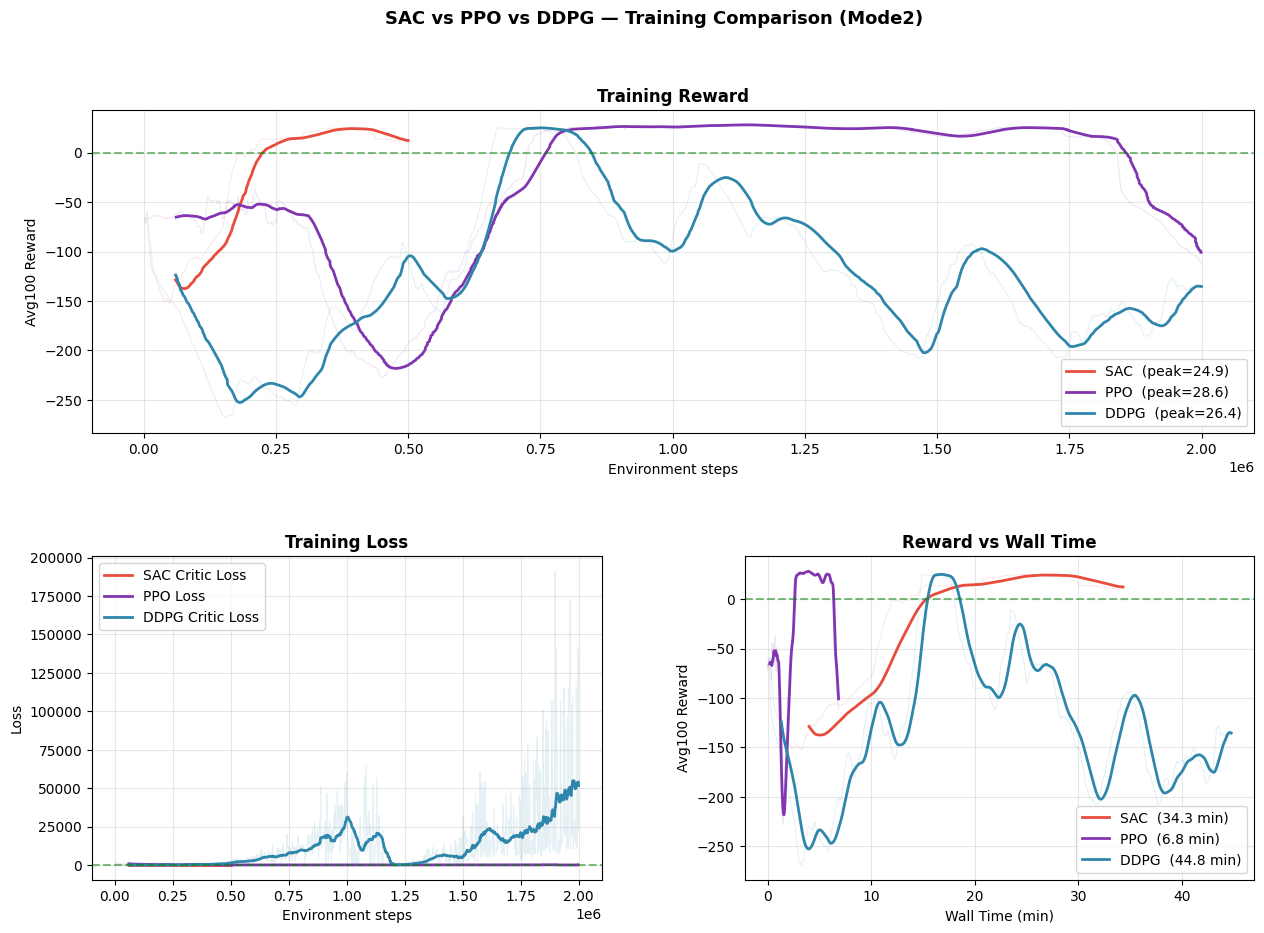

Saved: /Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data\three_way_training_model2.png

                                   SAC           PPO          DDPG
  Wall time (min)                 34.3           6.8          44.8
  Peak reward                     24.9          28.6          26.4
  Final reward                    10.4        -111.9        -133.7

[Running SAC episode...]
  Result: [230.74197    170.47263     64.80962    ...  -2.2810102   -0.27996302
   1.6863346 ]  duration=2.2s  max_x=1.753m

[Running PPO episode...]
  Result: [ 2.18049103e+02  2.13792206e+02  2.05090469e+02  1.95872940e+02
  1.85809784e+02  1.74426025e+02  1.61133118e+02  1.45350342e+02
  1.26506210e+02  1.04342163e+02  7.93859329e+01  5.30056953e+01
  2.70222435e+01  3.08287144e+00 -1.77844162e+01 -3.52334366e+01
 -4.93764267e+01 -6.05375748e+01 -6.91065216e+01 -7.54652634e+01
 -7.99592133e+01 -8.28891983e+01 -8.45130692e+01 -8.50500488e+01
 -8.46855621e+01 -8.35772171e+01 -8.18589020e+01

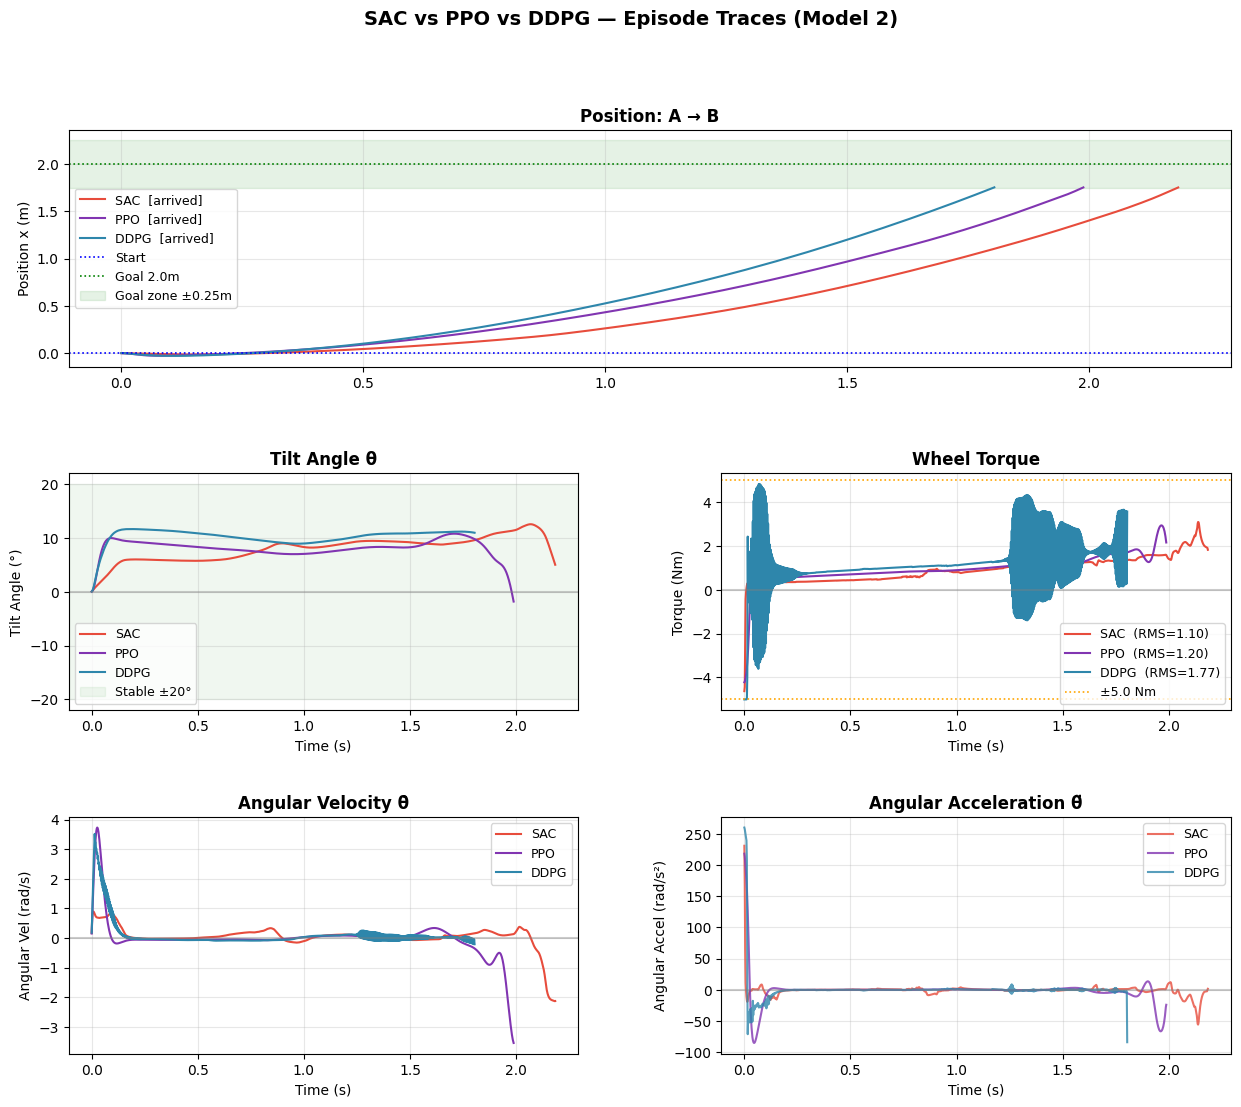

Saved: /Users/kchong99/Documents/Master/ME 569/owsbr/Arthur/Ozzy_Segway_Data/three_way_traces_model2.png

                                   SAC           PPO          DDPG
  Duration (s)                     2.2           2.0           1.8
  Max x (m)                      1.753         1.753         1.754
  Final x (m)                    1.753         1.753         1.754
  Avg tilt (deg)                   8.0           8.1          10.2
  Peak θ̇ (rad/s)                 2.13          3.73          3.52
  Peak θ̈ (rad/s²)              230.74        218.05        259.88
  Torque RMS (Nm)                1.102         1.201         1.773
  Result                       arrived       arrived       arrived

All done.


In [24]:

# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════
if __name__=="__main__":
    print("="*60)
    print("  SAC vs PPO vs DDPG — Three-Way Comparison")
    print("="*60)

    # load logs (PPO truncated to STEP_LIMIT)
    print("\nLoading logs...")
    sac_log  = load_log(SAC_LOG_PATH)
    ppo_log  = load_log(PPO_LOG_PATH,  step_limit=STEP_LIMIT)
    ddpg_log = load_log(DDPG_LOG_PATH)
    for name,d in [("SAC",sac_log),("PPO",ppo_log),("DDPG",ddpg_log)]:
        print(f"  {name}: {len(d['steps'])} pts  peak={max(d['rewards']):.1f}  wall={d['wall_time']/60:.1f}min")

    print("\n[1/5] Training curves...")
    plot_training(sac_log, ppo_log, ddpg_log)

    # load weights and run episodes
    episodes=[]
    for name, WeightClass, wpath in [
        ("SAC",  NavActor,  SAC_WEIGHTS),
        ("PPO",  NavPPO,    PPO_WEIGHTS),
        ("DDPG", DDPGActor, DDPG_WEIGHTS),
    ]:
        print(f"\n[Running {name} episode...]")
        try:
            net=WeightClass(torque_max=TORQUE_MAX)
            net.load_state_dict(torch.load(wpath, map_location="cpu"))
            net.eval()
            ep=run_episode(net)
            print(f"  Result: {ep[4]}  duration={ep[0][-1]:.1f}s  max_x={max(ep[1]):.3f}m")
            episodes.append(ep)
        except Exception as e:
            print(f"  ERROR: {e}")
            import traceback; traceback.print_exc()
            episodes.append(None)

    if all(ep is not None for ep in episodes):
        print("\n[Plotting episode traces...]")
        plot_traces(episodes)
    else:
        missing=[n for n,(_, _c, _w) in zip(["SAC","PPO","DDPG"],
                 [(NavActor,SAC_WEIGHTS),(NavPPO,PPO_WEIGHTS),(DDPGActor,DDPG_WEIGHTS)])
                 if episodes[["SAC","PPO","DDPG"].index(n)] is None]
        print(f"\nSkipping traces — missing weights for: {missing}")

    print("\nAll done.")
